In [14]:
%load_ext kedro.ipython

import numpy as np
import pandas as pd
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
import lightgbm as lgb
import matplotlib.pyplot as plt

random_state = catalog.load('params:model_options.random_state')
test_size = catalog.load('params:model_options.test_size')

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


[01/12/25 16:06:43] INFO     Loading data from params:model_options.random_state                ]8;id=592008;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=943640;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\
                             (MemoryDataset)...                                                                    

                    INFO     Loading data from params:model_options.test_size                   ]8;id=104299;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=965361;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\
                             (MemoryDataset)...                                                                    

In [2]:
X_train, y_train = catalog.load('TI_train_feature'), catalog.load('TI_y_train_feature')
X_test, y_test = catalog.load('TI_test_feature'), catalog.load('TI_y_test_feature')

                    INFO     Loading data from TI_train_feature (CSVDataset)...                 ]8;id=278343;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=724142;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

[01/12/25 16:04:25] INFO     Loading data from TI_y_train_feature (CSVDataset)...               ]8;id=967727;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=618185;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_test_feature (CSVDataset)...                  ]8;id=299964;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=755665;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_y_test_feature (CSVDataset)...                ]8;id=831537;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=538681;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

In [6]:
gbmX_train, gbmX_val, gbmY_train, gbmY_val = train_test_split(
    X_train, y_train, test_size=test_size, random_state=random_state
)

weights = compute_sample_weight('balanced', gbmY_train)

train_data = lgb.Dataset(data=gbmX_train, label=gbmY_train, weight=weights)
val_data = lgb.Dataset(data=gbmX_val, label=gbmY_val, reference=train_data)

In [7]:
param = {'num_leaves': 31, 'objective': 'binary'}
param['metric'] = 'average_precision'

num_round = 10
bst = lgb.train(param, train_data, num_round, valid_sets=[val_data])

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 603, number of negative: 39925
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003608 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2861
[LightGBM] [Info] Number of data points in the train set: 40528, number of used features: 24
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


In [12]:
y_proba = bst.predict(X_test)


array([0.44233777, 0.26733089, 0.36503535, ..., 0.27128704, 0.35026194,
       0.22018373])

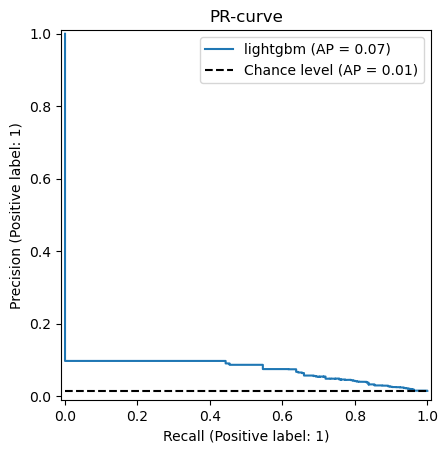

In [15]:
display = PrecisionRecallDisplay.from_predictions(
    y_test.T.values[0], y_proba, name='lightgbm', plot_chance_level=True
)
_ = display.ax_.set_title("PR-curve")
plt.legend()
plt.show()

12666